In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

In [2]:
np.random.seed(42)

data = pd.DataFrame({
    "Department": ["CSE", "ECE", "ME", "CE", "EEE"],
    "Students_2022": [120, 100, 80, 70, 60],
    "Students_2023": [140, 110, 90, 65, 75]
})

scores = pd.DataFrame({
    "Marks": np.random.normal(70, 10, 200)
})

scores_multi = pd.DataFrame({
    "Group": np.repeat(["A", "B"], 200),
    "Marks": np.hstack([
        np.random.normal(65, 8, 200),
        np.random.normal(75, 10, 200)
    ])
})

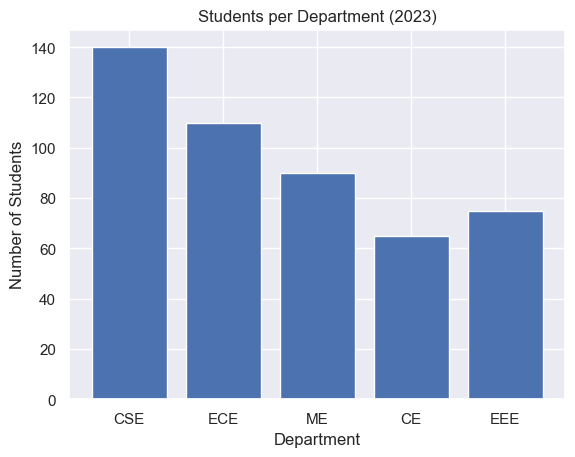

In [3]:
plt.bar(data["Department"], data["Students_2023"])
plt.xlabel("Department")
plt.ylabel("Number of Students")
plt.title("Students per Department (2023)")
plt.show()

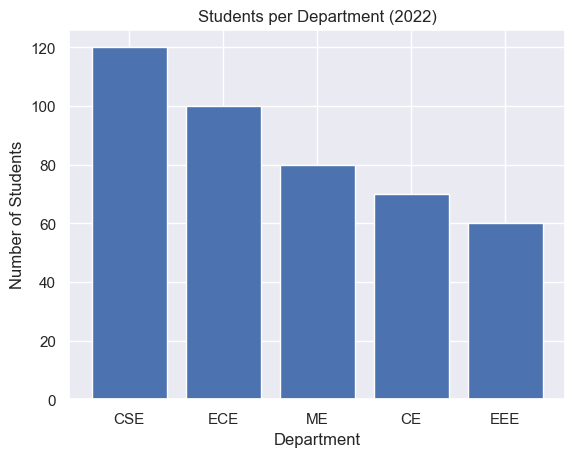

In [5]:
plt.bar(data["Department"], data["Students_2022"])
plt.xlabel("Department")
plt.ylabel("Number of Students")
plt.title("Students per Department (2022)")
plt.show()

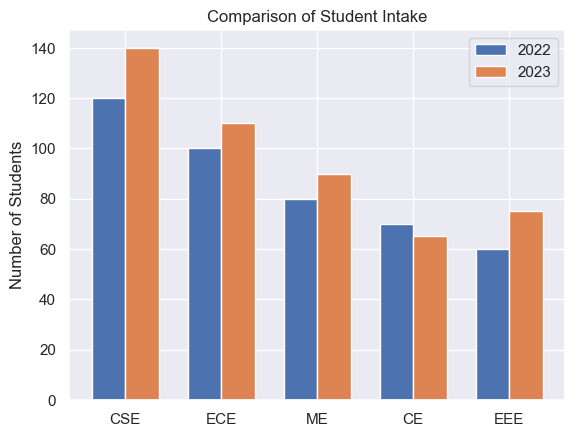

In [4]:
x = np.arange(len(data["Department"]))
width = 0.35

plt.bar(x - width/2, data["Students_2022"], width, label="2022")
plt.bar(x + width/2, data["Students_2023"], width, label="2023")

plt.xticks(x, data["Department"])
plt.ylabel("Number of Students")
plt.title("Comparison of Student Intake")
plt.legend()
plt.show()

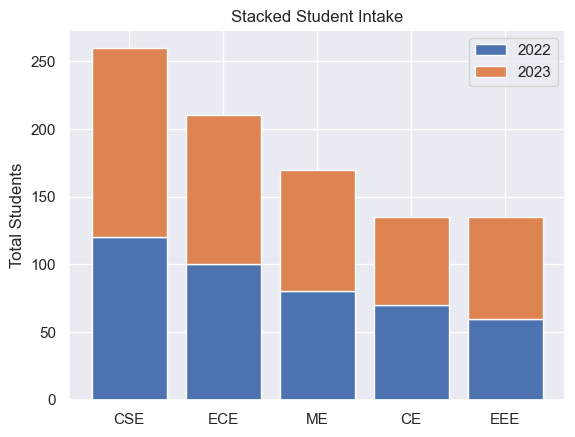

In [6]:
plt.bar(data["Department"], data["Students_2022"], label="2022")
plt.bar(data["Department"], data["Students_2023"],
        bottom=data["Students_2022"], label="2023")

plt.ylabel("Total Students")
plt.title("Stacked Student Intake")
plt.legend()
plt.show()

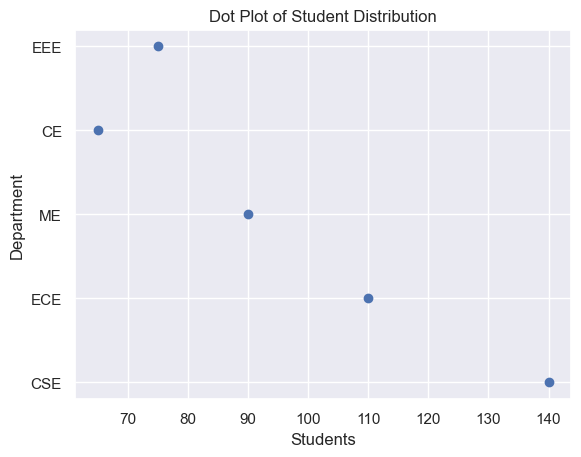

In [7]:
plt.plot(data["Students_2023"], data["Department"], "o")
plt.xlabel("Students")
plt.ylabel("Department")
plt.title("Dot Plot of Student Distribution")
plt.show()

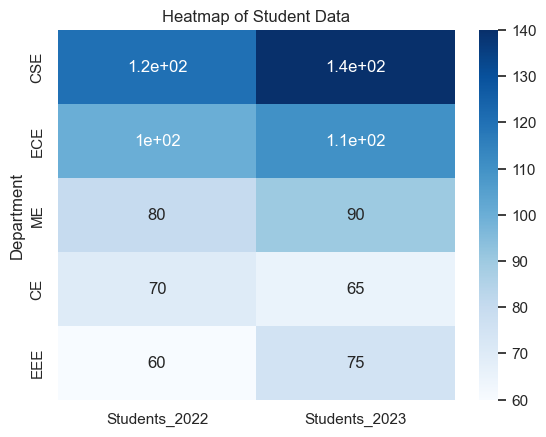

In [8]:
sns.heatmap(data.set_index("Department"),
            annot=True, cmap="Blues")

plt.title("Heatmap of Student Data")
plt.show()

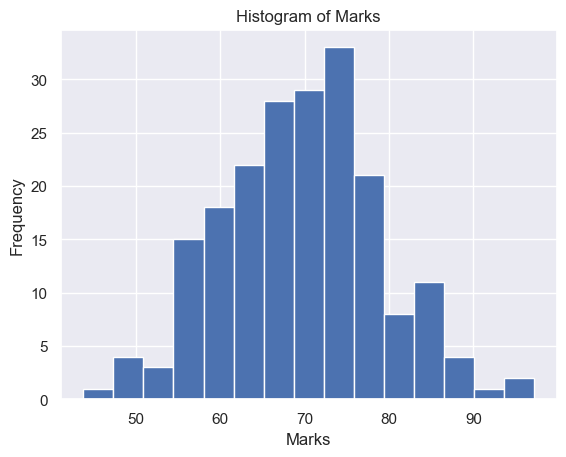

In [9]:
plt.hist(scores["Marks"], bins=15)
plt.xlabel("Marks")
plt.ylabel("Frequency")
plt.title("Histogram of Marks")
plt.show()

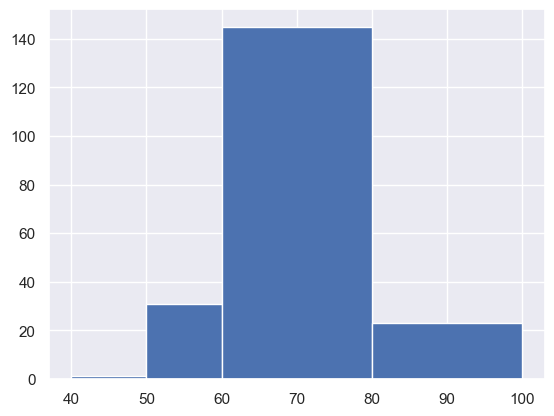

In [15]:
plt.hist(scores["Marks"], bins=[40, 50, 60, 80, 100])
plt.show()

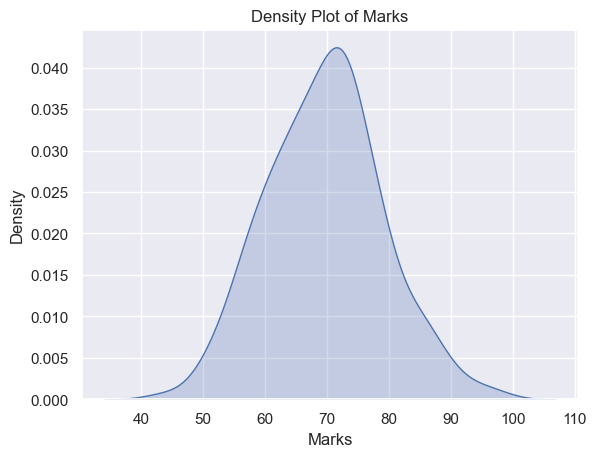

In [10]:
 sns.kdeplot(scores["Marks"], fill=True)
plt.title("Density Plot of Marks")
plt.xlabel("Marks")
plt.show()

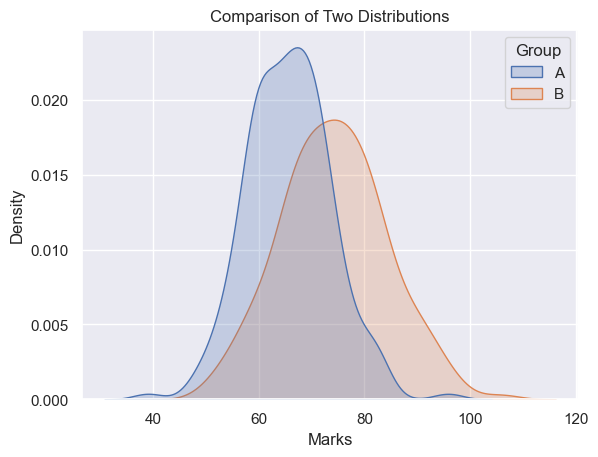

In [11]:
sns.kdeplot(data=scores_multi,
            x="Marks", hue="Group",
            fill=True)

plt.title("Comparison of Two Distributions")
plt.show()

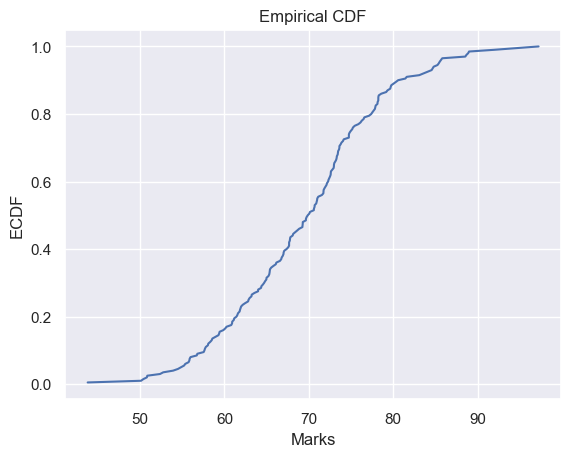

In [12]:
x = np.sort(scores["Marks"])
y = np.arange(1, len(x)+1) / len(x)

plt.plot(x, y)
plt.xlabel("Marks")
plt.ylabel("ECDF")
plt.title("Empirical CDF")
plt.show()

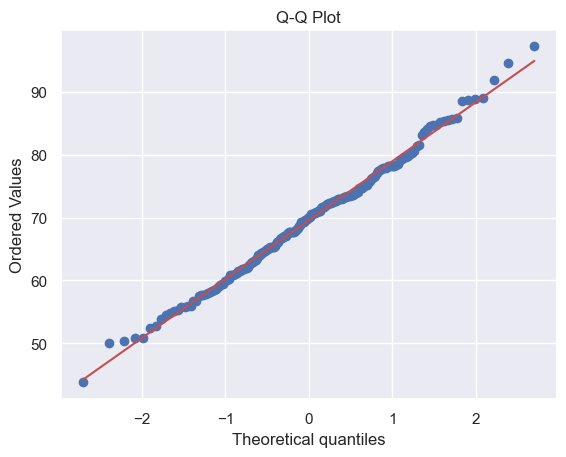

In [13]:
import scipy.stats as stats

stats.probplot(scores["Marks"], plot=plt)
plt.title("Q-Q Plot")
plt.show()

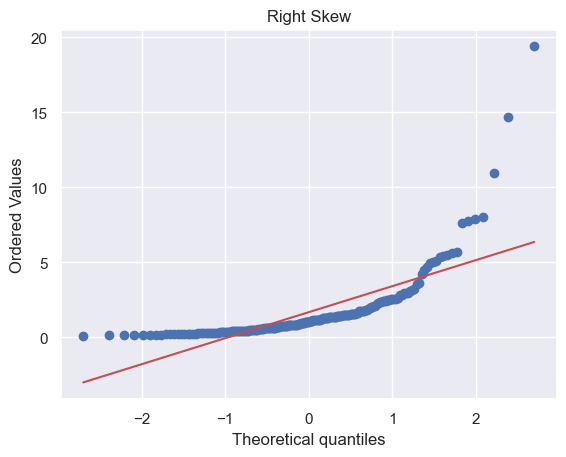

In [23]:
import scipy.stats as stats

right_skew = np.exp((scores["Marks"] - scores["Marks"].mean()) / scores["Marks"].std())

stats.probplot(right_skew, plot=plt)
plt.title("Right Skew")
plt.show()

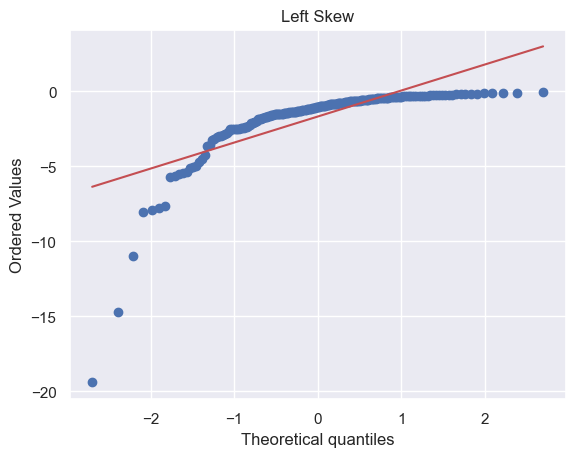

In [24]:
left_skew = -np.exp((scores["Marks"] - scores["Marks"].mean()) / scores["Marks"].std())

stats.probplot(left_skew, plot=plt)
plt.title("Left Skew")
plt.show()

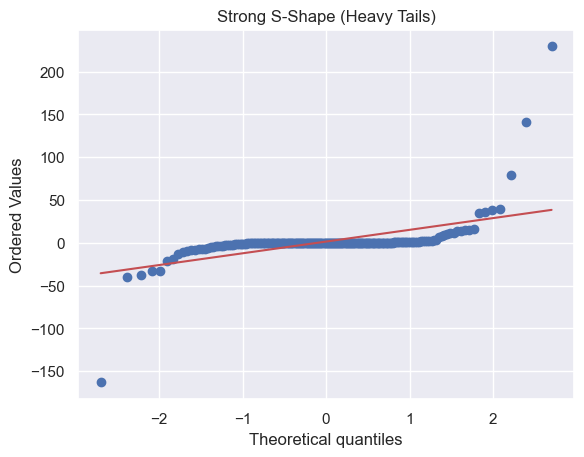

In [32]:
import scipy.stats as stats

z = (scores["Marks"] - scores["Marks"].mean()) / scores["Marks"].std()

heavy_tail = z**5   # stronger than cube → clearer S

stats.probplot(heavy_tail, plot=plt)
plt.title("Strong S-Shape (Heavy Tails)")
plt.show()

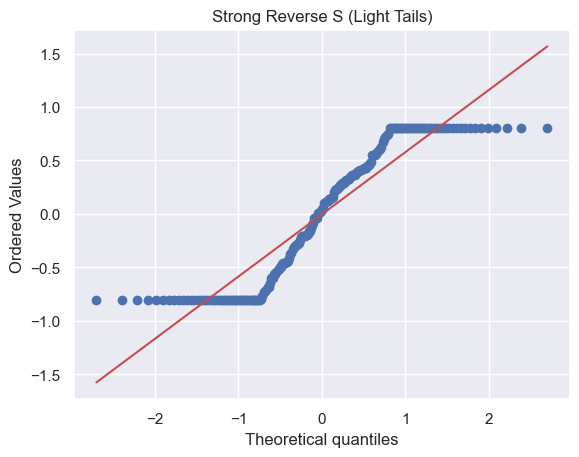

In [33]:
z = (scores["Marks"] - scores["Marks"].mean()) / scores["Marks"].std()

light_tail = np.clip(z, -0.8, 0.8)   # HARD compression

stats.probplot(light_tail, plot=plt)
plt.title("Strong Reverse S (Light Tails)")
plt.show()